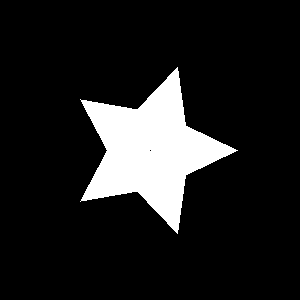

In [106]:
from PIL import Image, ImageDraw
import numpy as np
import math

W,H=300,300
center=(150, 150)  # Center of the star
# Create a black 300x300 image
img = Image.new("RGB", (W, H), "black")
draw = ImageDraw.Draw(img)

# Star center from the notebook
cx, cy = float(center[0]), float(center[1])

# Star geometry
outer_radius = 87
inner_radius = 43
arm_thickness=87
#arm_thickness = 13/np.sin(np.radians(36))

def star_points(cx, cy, outer_r, inner_r, rotation_deg=0):
    pts = []
    for i in range(10):
        r = outer_r if i % 2 == 0 else inner_r
        angle = math.radians(rotation_deg + i * 36)
        pts.append((
            int(round(cx + r * math.cos(angle))),
            int(round(cy + r * math.sin(angle)))
        ))
    return pts

# Draw solid star first
outer_pts = star_points(cx, cy, outer_radius, inner_radius)
draw.polygon(outer_pts, fill="white")

# Draw downscaled star on top to create hollow effect with uniform arm thickness
scale_factor = (outer_radius - arm_thickness) / outer_radius
scaled_outer_radius = outer_radius - arm_thickness
scaled_inner_radius = inner_radius * scale_factor
inner_outer_pts = star_points(cx, cy, scaled_outer_radius, scaled_inner_radius)
draw.polygon(inner_outer_pts, fill="black")

outline=13
#draw.circle((cx,cy),radius=outer_radius+outline,fill=None,outline="white",width=outline-1)
img.save("solid_star.png")
img

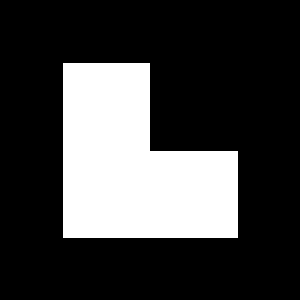

In [19]:
from PIL import Image, ImageDraw
import numpy as np

H,W=300,300
center=(H//2,W//2)
width=174
radius=width//2
img_circle=Image.new("RGB", (W, H), "black")
draw=ImageDraw.Draw(img_circle)
draw.ellipse((center[0]-radius, center[1]-radius, center[0]+radius, center[1]+radius), fill="white")
img_circle

img_L=Image.new('RGB', (W, H), 'black')
draw_L=ImageDraw.Draw(img_L)
bounding=[center[0]-radius, center[1]-radius, center[0]+radius, center[1]+radius]
draw_L.rectangle(bounding,fill='white')
deleting=[(center[0],center[1]-radius),(center[0]+radius,center[1])]
draw_L.rectangle(deleting,fill='black')
img_L

230.4
161.28


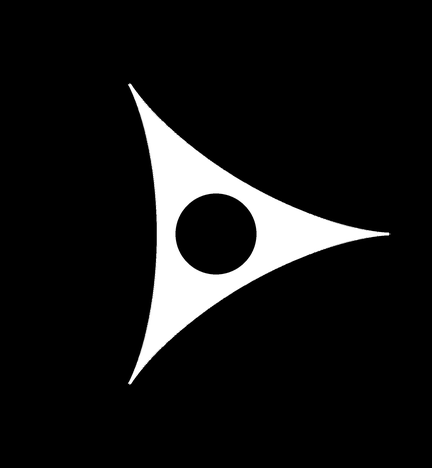

In [99]:
from PIL import Image, ImageDraw
import math

# Output size
WIDTH, HEIGHT = 432, 468
UPSCALE = 4  # draw larger for antialiasing then downsample
W, H = WIDTH * UPSCALE, HEIGHT * UPSCALE

# Create black canvas
img = Image.new("RGB", (W, H), "black")
draw = ImageDraw.Draw(img)

# Tricuspoid (deltoid) param: x = s*(2 cos t + cos 2t), y = s*(2 sin t - sin 2t)
# Choose scale so curve fits with margin
s = 0.8 * (min(W, H) / 2) / 3.0
print(s)
cx, cy = W / 2.0, H / 2.0

# Sample points
points = []
steps = 2000
for i in range(steps + 1):
    t = 2 * math.pi * i / steps
    x = s * (2 * math.cos(t) + math.cos(2 * t))
    y = s * (2 * math.sin(t) - math.sin(2 * t))
    points.append((cx + x, cy + y))

# Fill the curve
draw.polygon(points, fill=(255, 255, 255))
radius=s*0.7
print(radius)
draw.circle((cx, cy), radius, fill=(0, 0, 0))  # cut out the center


# Draw white curve (thicker while upscaled for smoother final)
stroke = max(1, UPSCALE * 3)
draw.line(points, fill=(255, 255, 255), width=stroke)

# Downsample for anti-aliasing and save
out = img.resize((WIDTH, HEIGHT), Image.LANCZOS)
out.save("tricuspoid_DLP.png")
out

In [42]:
import numpy as np
from PIL import Image,ImageDraw
import matplotlib.pyplot as plt

H,W=160*2,256*2
img=Image.new('RGB',(W,H),'black')
p1=Image.open('.\\GEO\\patches\\t1.png')
h,w=p1.size
box1=((256-w)//2,(160-h)//2,(256-w)//2+w,(160-h)//2+h)

p2=Image.open('.\\GEO\\patches\\t2.png')
box2=((256-w)//2+256,(160-h)//2,(256+w)//2+256,(160+h)//2)

p3=Image.open('.\\GEO\\patches\\t3.png')
box3=((256-w)//2,(160-h)//2+160,(256+w)//2,(160+h)//2+160)

p4=Image.open('.\\GEO\\patches\\t4.png')
box4=((256-w)//2+256,(160-h)//2+160,(256+w)//2+256,(160+h)//2+160)

img.paste(p1,box1)
img.paste(p2,box2)
img.paste(p3,box3)
img.paste(p4,box4)
img.save('./GEO/teeth.png')

In [1]:
#Here we do the image segementation

from PIL import Image, ImageDraw
H,W=160*2,256*2
img=Image.new('RGB',(W,H),'black')
draw=ImageDraw.Draw(img)

box1=(W/2-180,H/2-100,W/2+1-180,H/2+100)
draw.rectangle(box1,fill='white')
box2=(W/2-120,H/2-100,W/2+3-120,H/2+100)
draw.rectangle(box2,fill='white')
box3=(W/2-60,H/2-100,W/2+5-60,H/2+100)
draw.rectangle(box3,fill='white')
box4=(W/2,H/2-100,W/2+7,H/2+100)
draw.rectangle(box4,fill='white')
box5=(W/2+60,H/2-100,W/2+9+60,H/2+100)
draw.rectangle(box5,fill='white')
box6=(W/2+120,H/2-100,W/2+11+120,H/2+100)
draw.rectangle(box6,fill='white')
img.save('./GEO/sync.png')

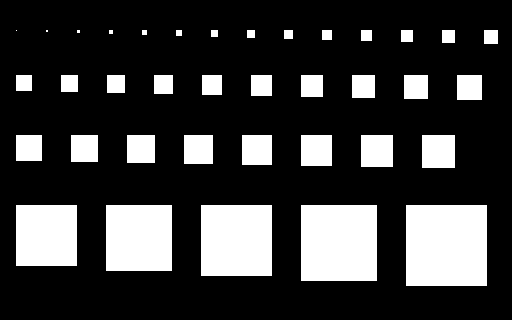

In [298]:
from PIL import Image, ImageDraw
img=Image.new('RGB',(256*2,160*2),'black')
draw=ImageDraw.Draw(img)
w,h=img.size
w_start=w/2-240
for width in np.arange(0, 14, 1): #14squares
    box1=(w_start,h/2-130,w_start+width,h/2+width-130)
    draw.rectangle(box1,fill='white')
    w_start=w_start+width+30
    h_start+=width
w_start=w/2-240
for width in np.arange(15, 25, 1): #10squares
    box1=(w_start,h/2-85,w_start+width,h/2+width-85)
    draw.rectangle(box1,fill='white')
    w_start=w_start+width+30
w_start=w/2-240
for width in np.arange(25, 33, 1): #8squares
    box1=(w_start,h/2-25,w_start+width,h/2+width-25)
    draw.rectangle(box1,fill='white')
    w_start=w_start+width+30
w_start=w/2-240
for width in np.arange(60, 85, 5): #5squares
    box1=(w_start,h/2+45,w_start+width,h/2+width+45)
    draw.rectangle(box1,fill='white')
    w_start=w_start+width+30
    
img_np=np.array(img.convert('L'))
np.savetxt('./GEO/Sync_rect_dimension.txt',img_np,fmt='%d')

img.save('./GEO/Sync_rect.png')
img

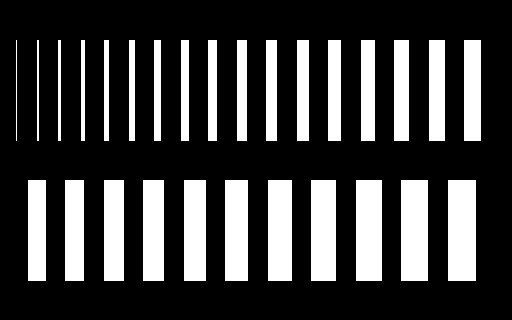

In [1]:
from PIL import Image, ImageDraw
import numpy as np
img=Image.new('RGB',(256*2,160*2),'black')
w,h=img.size
draw=ImageDraw.Draw(img)
w_start = w/2 - 240
for w1 in np.arange(1, 18, 1): #17lines
    draw.line(((w_start, h/2-120), (w_start, h/2-20)), fill='white', width=w1)
    w_start += w1 + 20

w_start = w/2 - 220
for ww in np.arange(18, 29, 1): #11lines
    draw.line(((w_start, h/2+20), (w_start, h/2+120)), fill='white', width=ww)
    w_start += ww + 20

img_np=np.array(img.convert('L'))
np.savetxt('./GEO/Sync_line_dimenson.txt',img_np,fmt='%d')
img.save('./GEO/Sync_line.png')
img